Load data, libraries and functions


In [105]:
# Standard libraries
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns
import shutil
import os

from scipy.io import wavfile
from scipy.signal import wiener

# Load data
DATA_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME")
AUDIO_PATH = DATA_PATH / "mic1_trim_v1~"
META_AUDIO_PATH = DATA_PATH / "meta_audio.csv"
META_PARTICIPANT_PATH = DATA_PATH / "meta_participant.csv"
AUDIO_BASE_PATH = DATA_PATH / "mic1_trim_v1~" / "mic1_trim_v2"

# Check everything exists
assert DATA_PATH.exists(), "Data map niet gevonden!"
assert AUDIO_PATH.exists(), "Audio map niet gevonden!"
assert META_AUDIO_PATH.exists(), "meta_audio.csv niet gevonden!"
assert META_PARTICIPANT_PATH.exists(), "meta_participant.csv niet gevonden!"

print("The paths are correct")

# Load metadata
meta_audio = pd.read_csv(META_AUDIO_PATH)
meta_participant = pd.read_csv(META_PARTICIPANT_PATH)

print("\nMeta audio shape:", meta_audio.shape)
print("Meta participant shape:", meta_participant.shape)

# Collect audio files
audio_files = list(AUDIO_PATH.rglob("*.wav"))

print(f"\nNumber of audio files: {len(audio_files)}")

The paths are correct

Meta audio shape: (7044, 9)
Meta participant shape: (51, 11)

Number of audio files: 14088


Select different participants based on gender and ethnicity


In [106]:
def load_meta_participant(file_path):
    """
    Load meta_participant
    """
    df = pd.read_csv(file_path)

    #Split columns with ',' 
    if df.shape[1] == 1:
        first_col = df.columns[0]
        split_df = df[first_col].str.split(",", expand=True)
        split_df.columns = first_col.split(",")
        df = split_df.copy()

    # Delete spaties 
    df.columns = [col.strip() for col in df.columns]

    return df


def stratified_participant_sample(
    file_path,
    n=20,
    gender_col="GENDER",
    race_col="RACE/ETHNICITY",
    id_col="PID",
    random_state=42
):
    """
    Selects n participants while preserving the distribution of gender and race/ethnicity
    as closely as possible.

    Parameters:
    file_path : str
        Path to meta_participant.csv
    n : int
        Number of participants
    gender_col : str
        Name of gender column 
    race_col : str
        Name of race/ethnicity column
    id_col : str
        Name of participant-ID kolom
    random_state : int
        random state = 42, random selection

    Returns:
    sample_df : pd.DataFrame
        Selected participants
    """
    df = load_meta_participant(file_path).copy()

    # Relevant columns
    needed_cols = [id_col, gender_col, race_col]
    for col in needed_cols:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

    # Drop missing values 
    df = df.dropna(subset=[gender_col, race_col]).copy()

    if n > len(df):
        raise ValueError(f"You ask {n} participants, but there are {len(df)} available.")

    # strata gender and race
    df["stratum"] = df[gender_col].astype(str).str.strip() + " | " + df[race_col].astype(str).str.strip()

    # size per stratum
    stratum_counts = df["stratum"].value_counts().sort_index()
    proportions = stratum_counts / len(df)

    # initial allocatie
    target_counts = proportions * n
    allocated = np.floor(target_counts).astype(int)

    # distribute remaining samples 
    remainder = n - allocated.sum()
    fractional_parts = (target_counts - allocated).sort_values(ascending=False)

    for stratum in fractional_parts.index[:remainder]:
        allocated[stratum] += 1

    # ensure we never sample more than available
    allocated = pd.Series({
        stratum: min(allocated[stratum], stratum_counts[stratum])
        for stratum in allocated.index
    })

    # fill up if neccessary due to rounding
    current_total = allocated.sum()
    if current_total < n:
        shortfall = n - current_total

        spare_capacity = pd.Series({
            stratum: stratum_counts[stratum] - allocated[stratum]
            for stratum in allocated.index
        }).sort_values(ascending=False)

        for stratum in spare_capacity.index:
            if shortfall == 0:
                break
            if spare_capacity[stratum] > 0:
                extra = min(spare_capacity[stratum], shortfall)
                allocated[stratum] += extra
                shortfall -= extra

    # draw the sample
    sampled_parts = []
    for stratum, k in allocated.items():
        if k > 0:
            subset = df[df["stratum"] == stratum]
            sampled_parts.append(subset.sample(n=k, random_state=random_state))

    sample_df = pd.concat(sampled_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    sample_df = sample_df.drop(columns=["stratum"])

    return sample_df


def print_sample_summary(sample_df, gender_col="GENDER", race_col="RACE/ETHNICITY", id_col= "PID"):
    """
    Summary selected sample
    """
    print(f"Number of selected participants : {len(sample_df)}\n")

    print("Distribution gender:")
    print(sample_df[gender_col].value_counts(dropna=False))
    print()

    print("Distribution race/ethnicity:")
    print(sample_df[race_col].value_counts(dropna=False))
    print()

    print("Selection of participants:")
    print(sample_df[id_col].tolist())
    print()

#output
sample_20 = stratified_participant_sample(
    file_path=r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME\meta_participant.csv",
    n=20,
    random_state=42
)

print_sample_summary(sample_20)

# opslaan
sample_20.to_csv("selected_participants_20.csv", index=False)

Number of selected participants : 20

Distribution gender:
GENDER
Woman         10
Man            8
Male           1
Non-binary     1
Name: count, dtype: int64

Distribution race/ethnicity:
RACE/ETHNICITY
Asian                11
White                 6
Hispanic/Latino       2
Two or more races     1
Name: count, dtype: int64

Selection of participants:
['p80330', 'p28030', 'p60145', 'p64560', 'p79665', 'p68870', 'p68340', 'p77560', 'p59520', 'p79550', 'p91315', 'p15965', 'p68625', 'p18785', 'p97630', 'p10085', 'p20960', 'p62650', 'p37540', 'p94215']



From the selected participants, select the audio files with ACTION LABEL = 0 and no notes


In [107]:
def load_meta_audio(file_path):
    """
    Load meta_audio.csv, and divide the columns with '
    """
    df = pd.read_csv(file_path)

    if df.shape[1] == 1:
        first_col = df.columns[0]
        split_df = df[first_col].str.split(",", expand=True)
        split_df.columns = [col.strip() for col in first_col.split(",")]
        df = split_df.copy()

    df.columns = [col.strip() for col in df.columns]
    return df


def select_valid_audio_rows(meta_audio_path, selected_participants_df):
    """
    Select rows from meta_audio for the chosen participants only,
    where NOTES is empty and ACTION LABEL equals 0.
    """
    meta_audio_df = load_meta_audio(meta_audio_path).copy()

    # selected PID list
    selected_pids = selected_participants_df["PID"].astype(str).tolist()

    # keep only chosen participants
    filtered_df = meta_audio_df[meta_audio_df["PID"].astype(str).isin(selected_pids)].copy()

    # make notes empty
    filtered_df["NOTES"] = filtered_df["NOTES"].fillna("").astype(str).str.strip()

    # ACTION label 
    filtered_df["ACTION LABEL"] = pd.to_numeric(filtered_df["ACTION LABEL"], errors="coerce")

    # filter: NOTES empty and ACTION LABEL == 0
    filtered_df = filtered_df[
        (filtered_df["NOTES"] == "") &
        (filtered_df["ACTION LABEL"] == 0)
    ].copy()

    return filtered_df


def build_audio_paths(filtered_audio_df, audio_base_path, extension=".wav"):
    """
    Build the expected audio file path for each selected row.
    Filename format:
    PID.COND.UTTNUM.UTTID.wav
    Stored in:
    audio_base_path / PID / filename
    """
    df = filtered_audio_df.copy()

    # make sure components are strings without spaces
    df["PID"] = df["PID"].astype(str).str.strip()
    df["COND"] = df["COND"].astype(str).str.strip()
    df["UTTNUM"] = df["UTTNUM"].astype(str).str.strip()
    df["UTTID"] = df["UTTID"].astype(str).str.strip()

    # create filename
    df["filename"] = (
        df["PID"] + "." +
        df["COND"] + "." +
        df["UTTNUM"] + "." +
        df["UTTID"] + extension
    )

    # full path
    df["file_path"] = df.apply(
        lambda row: os.path.join(audio_base_path, row["PID"], row["filename"]),
        axis=1
    )

    # check existence
    df["file_exists"] = df["file_path"].apply(os.path.exists)

    return df

In [108]:
#output 
filtered_audio = select_valid_audio_rows(
    meta_audio_path=META_AUDIO_PATH,
    selected_participants_df=sample_20
)

audio_selection = build_audio_paths(
    filtered_audio_df=filtered_audio,
    audio_base_path=AUDIO_BASE_PATH,
    extension=".wav"
)

print("Number of selected audio rows:", len(audio_selection))
print("Number of existing files:", audio_selection["file_exists"].sum())
audio_selection.head()


# Save as CSV: selected_audio_files.csv
audio_selection_existing = audio_selection[audio_selection["file_exists"]].copy()
audio_selection_existing.to_csv("selected_audio_files_1.csv", index=False)

Number of selected audio rows: 1941
Number of existing files: 1941


Save the selection of participants wav files 

In [109]:
# Folder to save the selected original (non-Wiener) audio files
ORIGINAL_SELECTED_OUTPUT_DIR = os.path.join(DATA_PATH, "selected_original_audio")
os.makedirs(ORIGINAL_SELECTED_OUTPUT_DIR, exist_ok=True)

print("Original selected audio output directory:")
print(ORIGINAL_SELECTED_OUTPUT_DIR)

Original selected audio output directory:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME\selected_original_audio


In [110]:
def make_original_output_path(input_path, output_root):
    """
    Copy original selected audio to:
    output_root / PID / original_filename.wav
    """
    participant_id = os.path.basename(os.path.dirname(input_path))
    filename = os.path.basename(input_path)

    participant_output_dir = os.path.join(output_root, participant_id)
    os.makedirs(participant_output_dir, exist_ok=True)

    return os.path.join(participant_output_dir, filename)

In [111]:
# Copy selected original audio files to a separate folder
original_selected_rows = []

for _, row in audio_selection_existing.iterrows():
    input_path = row["file_path"]

    try:
        output_path = make_original_output_path(input_path, ORIGINAL_SELECTED_OUTPUT_DIR)

        # Copy original wav file
        shutil.copy2(input_path, output_path)

        row_dict = row.to_dict()
        row_dict["selected_original_file_path"] = output_path
        original_selected_rows.append(row_dict)

    except Exception as e:
        print(f"Error copying {input_path}: {e}")

# create dataframe and save as CSV
original_selected_audio_df = pd.DataFrame(original_selected_rows)
print("Number of copied original selected audio files:", len(original_selected_audio_df))
original_selected_audio_df.head()
original_selected_audio_df.to_csv("selected_audio_files_original.csv", index=False)
print("Saved: selected_audio_files_original.csv")

Number of copied original selected audio files: 1941
Saved: selected_audio_files_original.csv


Preprocessing: Wiener filtering

In [112]:
# Folder to save Wiener-filtered audio
WIENER_OUTPUT_DIR = os.path.join(DATA_PATH, "wiener_filtered_audio")
os.makedirs(WIENER_OUTPUT_DIR, exist_ok=True)

print("Wiener output directory:")
print(WIENER_OUTPUT_DIR)

Wiener output directory:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME\wiener_filtered_audio


In [113]:
def load_wav_file(file_path):
    """
    Load a WAV file and return sample rate and signal.
    """
    sample_rate, signal = wavfile.read(file_path)
    return sample_rate, signal


def apply_wiener_filter(signal, mysize=29, noise=None):
    """
    Apply Wiener filtering to an audio signal.
    
    Parameters
    ----------
    signal : np.ndarray
        Input audio signal
    mysize : int
        Wiener filter window size
    noise : float or None
        Noise power estimate
    """
    signal = signal.astype(np.float32) #Wiener filtering 
    filtered_signal = wiener(signal, mysize=mysize, noise=noise)
    return filtered_signal


def save_wav_file(file_path, sample_rate, signal):
    """
    Save a WAV file as int16.
    """
    signal = np.clip(signal, -32768, 32767)
    signal = signal.astype(np.int16) #deze is niet nodig als je omzet naar float 
    wavfile.write(file_path, sample_rate, signal)


def make_output_path(input_path, output_root):
    """
    Save filtered audio in:
    output_root / PID / original_filename.wav
    """
    participant_id = os.path.basename(os.path.dirname(input_path))
    filename = os.path.basename(input_path)

    participant_output_dir = os.path.join(output_root, participant_id)
    os.makedirs(participant_output_dir, exist_ok=True)

    return os.path.join(participant_output_dir, filename)


Wiener filtering on all files

In [114]:
processed_rows = []

for _, row in audio_selection_existing.iterrows():
    input_path = row["file_path"]

    try:
        sample_rate, signal = load_wav_file(input_path)

        # Apply Wiener filtering
        filtered_signal = apply_wiener_filter(signal, mysize=29)

        # Create output path
        output_path = make_output_path(input_path, WIENER_OUTPUT_DIR)

        # Save filtered file
        save_wav_file(output_path, sample_rate, filtered_signal)

        # Store row info
        row_dict = row.to_dict()
        row_dict["wiener_file_path"] = output_path
        processed_rows.append(row_dict)

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

wiener_audio_df = pd.DataFrame(processed_rows)

c:\Users\marti\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:1659: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
c:\Users\marti\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:1659: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


Save Wiener filtered Audio to CSV

In [115]:
wiener_audio_df = pd.DataFrame(processed_rows)
print("Number of Wiener audio files:", len(wiener_audio_df))
wiener_audio_df.to_csv("selected_audio_files_wiener.csv", index=False)
print("Saved: selected_audio_files_wiener.csv")



Number of Wiener audio files: 1941
Saved: selected_audio_files_wiener.csv


Plot wav signal of Original and Wiener Filter

Original file: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME\mic1_trim_v1~\mic1_trim_v2\p10085\p10085.LC.1.161.wav
Filtered file: C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\TAME\wiener_filtered_audio\p10085\p10085.LC.1.161.wav
Sample rate original: 16000
Sample rate filtered: 16000


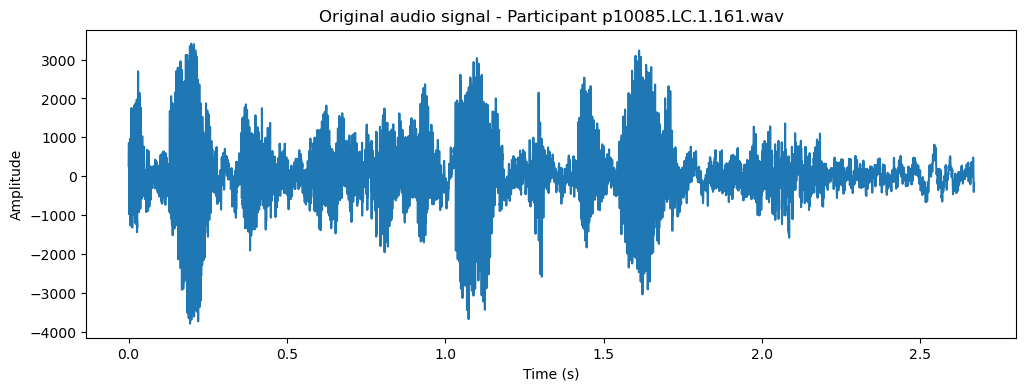

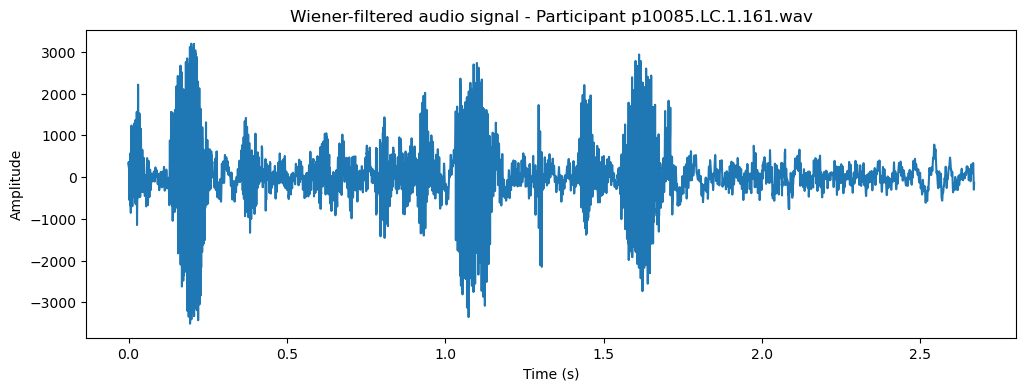

In [116]:
row = audio_selection_existing.iloc[0]

original_path = audio_selection_existing.iloc[0]["file_path"]
filtered_path = make_output_path(original_path, WIENER_OUTPUT_DIR)

sr_orig, signal_orig = load_wav_file(original_path)
sr_filt, signal_filt = load_wav_file(filtered_path)

print("Original file:", original_path)
print("Filtered file:", filtered_path)
print("Sample rate original:", sr_orig)
print("Sample rate filtered:", sr_filt)

# Time axis
time_orig = np.arange(len(signal_orig)) / sr_orig
time_filt = np.arange(len(signal_filt)) / sr_filt

#print participant
row = audio_selection_existing.iloc[0]
test_file = row["file_path"]
pid = row["PID"]
filename = os.path.basename(test_file)


#plot signal without Wiener 
plt.figure(figsize=(12, 4))
plt.plot(time_orig, signal_orig)
plt.title(f"Original audio signal - Participant {filename}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

#Plot wiener signal
plt.figure(figsize=(12, 4))
plt.plot(time_filt, signal_filt)
plt.title(f"Wiener-filtered audio signal - Participant {filename}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


Pain levels of selected participants 

In [122]:
def create_painlevel_table_from_audio_selection(audio_selection_df, pain_col="PAINLEVEL"):
    """
    Create pain level distribution table from the selected audio rows.
    This uses the already filtered audio selection.
    """
    df = audio_selection_df.copy()

    if pain_col not in df.columns:
        raise ValueError(f"'{pain_col}' not found in audio_selection_df. Available columns: {list(df.columns)}")

    df[pain_col] = pd.to_numeric(df[pain_col], errors="coerce")
    df = df.dropna(subset=[pain_col]).copy()
    df[pain_col] = df[pain_col].astype(int)

    painlevel_table = (
        df[pain_col]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    painlevel_table.columns = ["Painlevel", "N"]
    painlevel_table["Percentage"] = (painlevel_table["N"] / painlevel_table["N"].sum() * 100).round(1)

    return painlevel_table

painlevel_table_audio = create_painlevel_table_from_audio_selection(
    audio_selection_df=audio_selection_existing,
    pain_col="REVISED PAIN"   # pas aan indien nodig
)

print(painlevel_table_audio)
painlevel_table_audio.to_csv("painlevel_distribution_selected_audio.csv", index=False)

   Painlevel    N  Percentage
0          1  913        47.0
1          2  107         5.5
2          3  148         7.6
3          4  273        14.1
4          5  122         6.3
5          6  144         7.4
6          7  138         7.1
7          8   71         3.7
8          9   20         1.0
9         10    5         0.3
